In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, vonmises_fisher
import seaborn as sns
import sys
from tqdm import trange 

sys.path.append("../src")
from border_effects_kNN_del import knn_edges, rnn_edges, delaunay_edges_geodesic, delaunay_edges_on_subset_geodesic, knn_edges_on_subset, rnn_edges_on_subset, crop_and_dist_cap, reindex_edges_to_crop, delaunay_edges
from fit import fit_exponential_saturation, fit_piece_wise_linear, fit_constant, piecewise_plateau, exp_sat
from evaluate_fit import log_likelihood, akaike_information_criterion
from sern import surrogate_ensemble_gt, compute_centrality_measures
from sphere import sample_uniform_on_unit_sphere, sample_von_mises_fisher

/data/bionets/je30bery/conda/envs/trunc/lib/python3.9/site-packages/graph_tool/draw/cairo_draw.py:1557: RuntimeWarning: Error importing Gtk module: /data/bionets/je30bery/conda/envs/trunc/lib/python3.9/site-packages/gi/../../../libgobject-2.0.so.0: undefined symbol: g_string_copy; GTK+ drawing will not work.
  warnings.warn(msg, RuntimeWarning)


In [3]:
coords = np.array([[0,0], [0,1], [0,2], [1,0], [1,1], [1,2], [2,0], [2,1], [2,2]])

In [4]:
edges = delaunay_edges(coords)

In [5]:
centr = pd.DataFrame(compute_centrality_measures(edges))

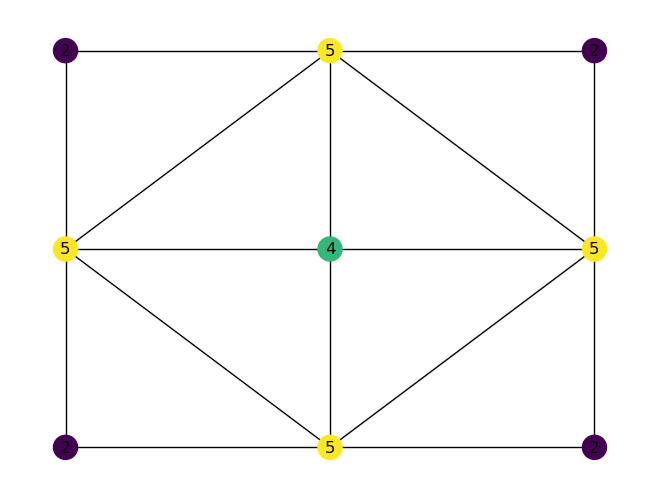

In [6]:
G = nx.from_edgelist(edges)
for i in G.nodes:
    G.nodes[i]["pos"] = coords[i]
nx.draw(G, pos=nx.get_node_attributes(G, "pos"), labels=centr["degree"], node_color=centr["degree"].values[G.nodes])

In [7]:
median = pd.DataFrame(surrogate_ensemble_gt(coords=coords, edge_list=edges, n_bins=10, n_surrogates=10, n_jobs=1))

SERN: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 178.41it/s]


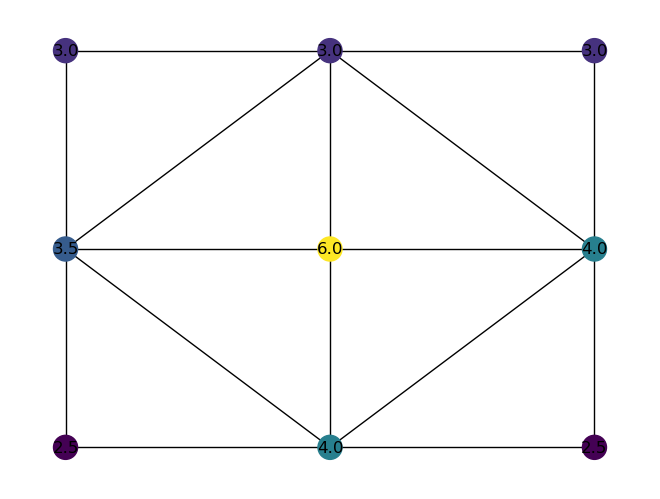

In [8]:
G = nx.from_edgelist(edges)
for i in G.nodes:
    G.nodes[i]["pos"] = coords[i]
nx.draw(G, pos=nx.get_node_attributes(G, "pos"), labels=median["degree"], node_color=median["degree"].values[G.nodes])

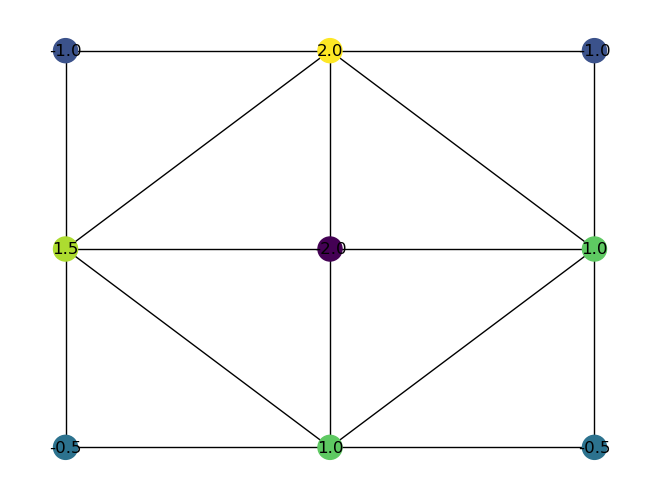

In [9]:
G = nx.from_edgelist(edges)
for i in G.nodes:
    G.nodes[i]["pos"] = coords[i]
nx.draw(G, pos=nx.get_node_attributes(G, "pos"), labels=centr["degree"]-median["degree"], node_color=(centr["degree"]-median["degree"]).values[G.nodes])

In [10]:
pearsonr(median["degree"], compute_centrality_measures(edges)['degree'])

PearsonRResult(statistic=0.4940272271396865, pvalue=0.1764569953390658)

In [11]:
coords = sample_von_mises_fisher(n=5000, kappas=[1, 3, 5])

In [29]:
radius_factor = 3
base_radius = 2 / np.sqrt(5000)
r = radius_factor * base_radius
edges = rnn_edges(coords, r=r)

In [30]:
original_centralities = pd.DataFrame(
    compute_centrality_measures(edges)
)   

<Axes: ylabel='Count'>

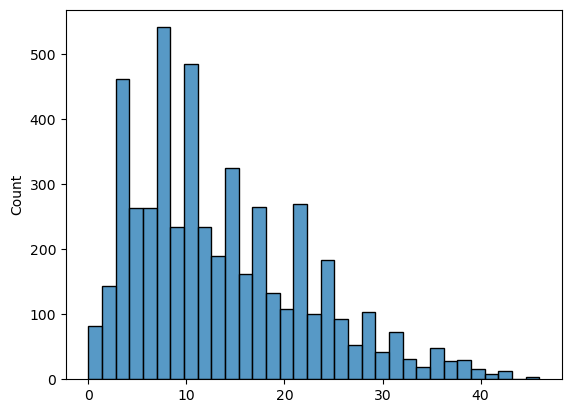

In [31]:
sns.histplot(original_centralities["degree"].values)

<Axes: ylabel='Count'>

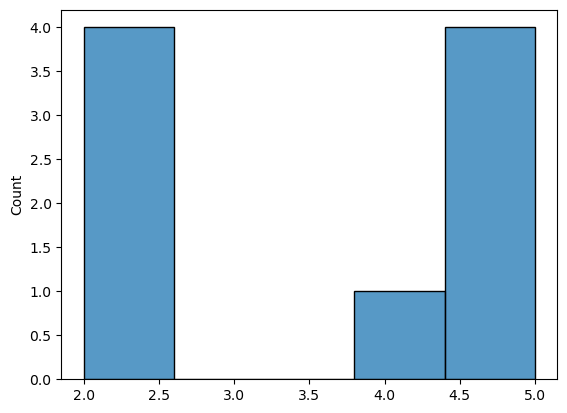

In [16]:
sns.histplot(centr["degree"].values)